In [1]:
%pip install uproot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.3/689.3 kB 56.1 MB/s eta 0:00:00


In [2]:
%pip install awkward_pandas

**NEW CLASSIFICATION**

In [3]:
# ==========================================================
# Three-Gamma CNN Regression
# Predict:
#   - Annihilation X
#   - Annihilation Y
#   - Annihilation Z
#   - Total deposited energy
# ==========================================================

import os
import numpy as np
import pandas as pd
import uproot

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [6]:
# ==========================================================
# Load ROOT file
# ==========================================================

ROOT_FILE = "new3merged.root"

file = uproot.open(ROOT_FILE)

print(file.keys())


['TwoG_NCS;1', 'TwoG_PhantomSCS;1', 'TwoG_ScannerSCS;1', 'TwoG_PhantomSCS_ScannerSCS;1', 'TwoG_PhantomDCS;1', 'TwoG_ScannerDCS;1', 'TwoG_PhantomSCS_ScannerDCS;1', 'TwoG_PhantomDCS_ScannerSCS;1', 'TwoG_PhantomDCS_ScannerDCS;1', 'TwoG_MCS;1', 'TwoG_Excluded;1', 'ThreeG_NCS;1', 'ThreeG_ScannerSCS;1', 'ThreeG_ScannerDCS;1', 'ThreeG_ScannerTCS;1', 'ThreeG_MCS;1', 'ThreeG_Excluded;1', 'Run;1']


In [9]:
# checking three chanells are identical

branches = [

    "RunID",
    "EventID",

    "GammaIndex",

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_ScannerTCS"]
df = tree.arrays(branches, library="pd")


print(df.head())

print(
    np.allclose(
        df["EnergyDeposit_keV"],
        df["PreEnergy_keV"]
    )
)

print(
    np.allclose(
        df["PostEnergy_keV"],
        0
    )
)

              RunID  EventID  GammaIndex       X_mm       Y_mm       Z_mm  \
0  slurm_35882963_1       41           0  -9.865292  50.433369  -1.978315   
1  slurm_35882963_1       41           0 -14.214360  57.286026  -8.685614   
2  slurm_35882963_1       41           1  36.760845 -41.223263   6.484430   
3  slurm_35882963_1       41           1  37.166439 -44.183380   6.876178   
4  slurm_35882963_1       41           2 -21.650757 -10.187035 -46.125771   

   EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  AnnihilY_mm  \
0          79.682426     372.859863      293.177429     4.741079    -0.819348   
1         293.177429     293.177429        0.000000     4.741079    -0.819348   
2          43.574589     408.952850      365.378265     4.741079    -0.819348   
3         365.378265     365.378265        0.000000     4.741079    -0.819348   
4          45.603512     240.185104      194.581589     4.741079    -0.819348   

   AnnihilZ_mm  
0   -10.627911  
1   -10.627911  

NameError: name 'images' is not defined

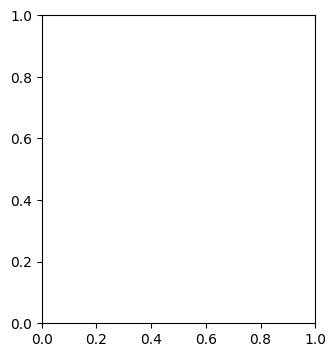

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(images[0][:,:,0])
plt.title("EnergyDeposit")

plt.subplot(1,3,2)
plt.imshow(images[0][:,:,1])
plt.title("PreEnergy")

plt.subplot(1,3,3)
plt.imshow(images[0][:,:,2])
plt.title("PostEnergy")

plt.show()

In [11]:
branches = [

    "RunID",
    "EventID",

    "GammaIndex",

    "X_mm",
    "Y_mm",
    "Z_mm",

    "EnergyDeposit_keV",
    "PreEnergy_keV",
    "PostEnergy_keV",

    "AnnihilX_mm",
    "AnnihilY_mm",
    "AnnihilZ_mm"

]

tree = file["ThreeG_NCS"]
df = tree.arrays(branches, library="pd")

print(df.head())

              RunID  EventID  GammaIndex       X_mm       Y_mm       Z_mm  \
0  slurm_35882963_1        0           0  42.213463 -29.997831 -44.219231   
1  slurm_35882963_1        0           1 -39.140385  43.925343  13.321461   
2  slurm_35882963_1        0           2  24.441950 -43.796162   5.251225   
3  slurm_35882963_1       14           0  25.520941  44.251762   1.901691   
4  slurm_35882963_1       14           1  50.743858  24.093874 -56.104988   

   EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV  AnnihilX_mm  AnnihilY_mm  \
0         382.314117     382.314117             0.0     4.632441    -1.534016   
1         481.058167     481.058167             0.0     4.632441    -1.534016   
2         158.625549     158.625549             0.0     4.632441    -1.534016   
3         214.394302     214.394302             0.0     0.514280     0.849866   
4         334.142273     334.142273             0.0     0.514280     0.849866   

   AnnihilZ_mm  
0   -10.633850  
1   -10.633850  

In [12]:
print()

print("Number of detector hits =", len(df))

print()

print("Number of events =",
      df[["RunID", "EventID"]].drop_duplicates().shape[0])

print()

print(df.describe())


Number of detector hits = 71052

Number of events = 23684

            EventID    GammaIndex          X_mm          Y_mm          Z_mm  \
count  71052.000000  71052.000000  71052.000000  71052.000000  71052.000000   
mean   50229.193675      1.000000      1.061749      2.208955     -6.028527   
std    28735.426307      0.816502     32.963696     33.103458     32.988747   
min        0.000000      0.000000    -97.966812    -96.540375    -99.812874   
25%    25521.750000      0.000000    -26.325434    -25.318258    -34.228518   
50%    50419.000000      1.000000      1.793689      3.208224     -9.021889   
75%    74917.500000      2.000000     28.715997     30.252709     20.529098   
max    99997.000000      2.000000     98.725464     98.295921     98.933701   

       EnergyDeposit_keV  PreEnergy_keV  PostEnergy_keV   AnnihilX_mm  \
count       71052.000000   71052.000000         71052.0  71052.000000   
mean          338.572937     338.572937             0.0      1.841628   
std      

In [13]:
IMG_SIZE = 64

xmin = df.X_mm.min()
xmax = df.X_mm.max()

ymin = df.Y_mm.min()
ymax = df.Y_mm.max()

print(xmin, xmax)
print(ymin, ymax)

-97.96681213378906 98.7254638671875
-96.54037475585938 98.2959213256836


In [40]:
# ==========================================================
# Create one 3-channel image per event
#
# Channel 0 = EnergyDeposit_keV
# Channel 1 = PreEnergy_keV
# Channel 2 = PostEnergy_keV
#
# Targets:
# X, Y, Z annihilation coordinates
# Total deposited energy
# ==========================================================

images = []
targets = []

event_groups = df.groupby(["RunID", "EventID"], sort=False)

# Define zmin and zmax before the loop, similar to xmin/xmax and ymin/ymax
zmin = df.Z_mm.min()
zmax = df.Z_mm.max()

print(f"Building images from {event_groups.ngroups} events...")


for i, ((run_id, event_id), event) in enumerate(event_groups):

    # All hits with this RunID and EventID belong to one event

    image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)

    # -----------------------------
    # Channel 0: XY projection
    # -----------------------------
    H_xy, _, _ = np.histogram2d(
        event["X_mm"],
        event["Y_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [ymin, ymax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 0] = H_xy


    # -----------------------------
    # Channel 1: XZ projection
    # -----------------------------
    H_xz, _, _ = np.histogram2d(
        event["X_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[xmin, xmax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 1] = H_xz


    # -----------------------------
    # Channel 2: YZ projection
    # -----------------------------
    H_yz, _, _ = np.histogram2d(
        event["Y_mm"],
        event["Z_mm"],
        bins=IMG_SIZE,
        range=[[ymin, ymax], [zmin, zmax]],
        weights=event["EnergyDeposit_keV"]
    )

    image[:, :, 2] = H_yz
    # -----------------------------
    # Regression Targets
    # -----------------------------

    annihil_x = event["AnnihilX_mm"].iloc[0]
    annihil_y = event["AnnihilY_mm"].iloc[0]
    annihil_z = event["AnnihilZ_mm"].iloc[0]

    target = [
        annihil_x,
        annihil_y,
        annihil_z,
    ]


    # -----------------------------
    # Store image and target
    # -----------------------------

    images.append(image)
    targets.append(target)


    if (i + 1) % 1000 == 0:
        print(f"{i+1} events processed")


# Convert lists to arrays
images = np.array(images, dtype=np.float16)
targets = np.array(targets, dtype=np.float32)


print()
print("Images shape :", images.shape)
print("Targets shape:", targets.shape)

Building images from 23684 events...
1000 events processed
2000 events processed
3000 events processed
4000 events processed
5000 events processed
6000 events processed
7000 events processed
8000 events processed
9000 events processed
10000 events processed
11000 events processed
12000 events processed
13000 events processed
14000 events processed
15000 events processed
16000 events processed
17000 events processed
18000 events processed
19000 events processed
20000 events processed
21000 events processed
22000 events processed
23000 events processed

Images shape : (23684, 64, 64, 3)
Targets shape: (23684, 3)


In [41]:
print("Images:", images.shape)
print("Targets:", targets.shape)

print("\nExample target:")
print(targets[0])

Images: (23684, 64, 64, 3)
Targets: (23684, 3)

Example target:
[  4.6324406  -1.5340159 -10.63385  ]


In [42]:
images /= np.max(images)

print(images.min())
print(images.max())

0.0
1.0


In [43]:
print("Images shape:", images.shape)
print("Targets shape:", targets.shape)

print("\nFirst target:")
print(targets[0])

Images shape: (23684, 64, 64, 3)
Targets shape: (23684, 3)

First target:
[  4.6324406  -1.5340159 -10.63385  ]


In [44]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    images,
    targets,
    test_size=0.2,
    random_state=42
)


print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

print("Training targets:", y_train.shape)
print("Testing targets:", y_test.shape)

Training images: (18947, 64, 64, 3)
Testing images: (4737, 64, 64, 3)
Training targets: (18947, 3)
Testing targets: (4737, 3)


In [45]:
from sklearn.preprocessing import StandardScaler


target_scaler = StandardScaler()


y_train_scaled = target_scaler.fit_transform(y_train)

y_test_scaled = target_scaler.transform(y_test)


print(y_train_scaled[0])

[-1.5680906   1.4992275   0.80531687]


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)


model = Sequential()


model.add(
    Conv2D(
        16,
        (3,3),
        activation="relu",
        input_shape=(64,64,3)
    )
)

model.add(MaxPooling2D())
model.add(BatchNormalization())

model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D())
model.add(BatchNormalization())

model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(MaxPooling2D())
model.add(BatchNormalization())

model.add(Flatten())


model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(Dropout(0.3))


model.add(Dense(3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae", 'accuracy']
)

In [49]:
from tensorflow.keras.callbacks import EarlyStopping


early_stop = EarlyStopping(
    patience=10,
    restore_best_weights=True
)


history = model.fit(
    X_train,
    y_train_scaled,
    validation_split=0.2,
    epochs=40,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6034 - loss: 0.6496 - mae: 0.6469 - val_accuracy: 0.5712 - val_loss: 0.7660 - val_mae: 0.7243
Epoch 2/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6021 - loss: 0.6401 - mae: 0.6411 - val_accuracy: 0.6011 - val_loss: 0.7011 - val_mae: 0.6650
Epoch 3/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6099 - loss: 0.6396 - mae: 0.6415 - val_accuracy: 0.6077 - val_loss: 0.6550 - val_mae: 0.6578
Epoch 4/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6078 - loss: 0.6389 - mae: 0.6411 - val_accuracy: 0.6153 - val_loss: 0.6542 - val_mae: 0.6564
Epoch 5/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6067 - loss: 0.6367 - mae: 0.6400 - val_accuracy: 0.6174 - val_loss: 0.6769 - val_mae: 0.6709
Epoch 6/40
1895/1895 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6109 - loss: 0.6304 - mae: 0.6368 - val_accuracy: 0.6150 - val_loss: 0.6400 - val_mae: 0.6423
Epoch 7/40
1895/1895 ━━━━━━

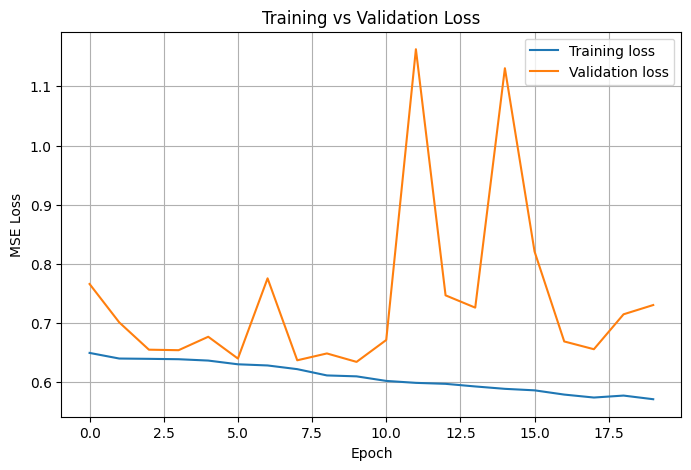

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()

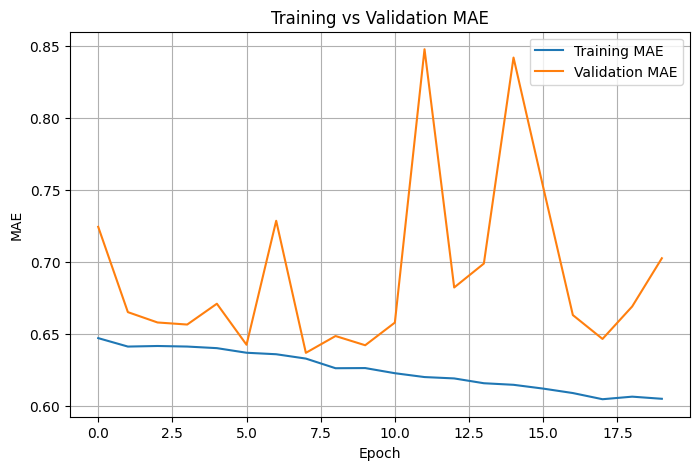

In [51]:
plt.figure(figsize=(8,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")

plt.legend()
plt.grid()

plt.show()

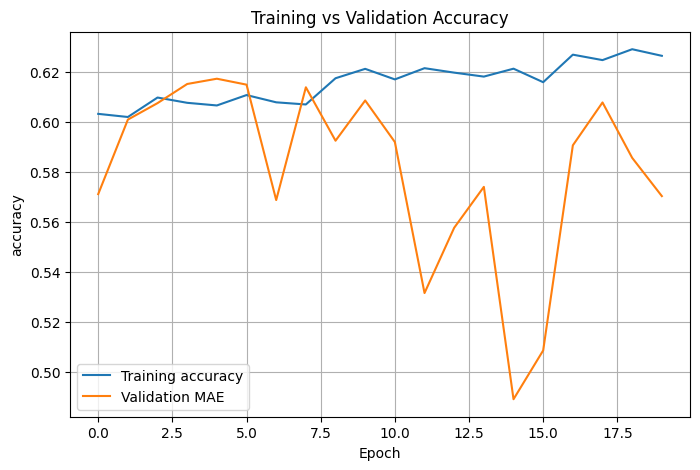

In [52]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

In [53]:
test_loss, test_mae, test_accuracy = model.evaluate(
    X_test,
    y_test_scaled
)

print("Test loss:", test_loss)
print("Test MAE:", test_mae)
print("Test accuracy:", test_accuracy)

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6111 - loss: 0.6455 - mae: 0.6499
Test loss: 0.6454575657844543
Test MAE: 0.6499372124671936
Test accuracy: 0.6111462712287903


In [54]:
prediction_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(prediction_scaled)

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [ ]:
for i in range(5):
    print("True:     ", y_test[i])
    print("Predicted:", prediction[i])
    print()

In [55]:
position_error = prediction[:,:3] - y_test[:,:3]


distance_error = np.sqrt(
    position_error[:,0]**2 +
    position_error[:,1]**2 +
    position_error[:,2]**2
)


print(
    "Mean annihilation position error:",
    np.mean(distance_error),
    "mm"
)

Mean annihilation position error: 2.7667196 mm


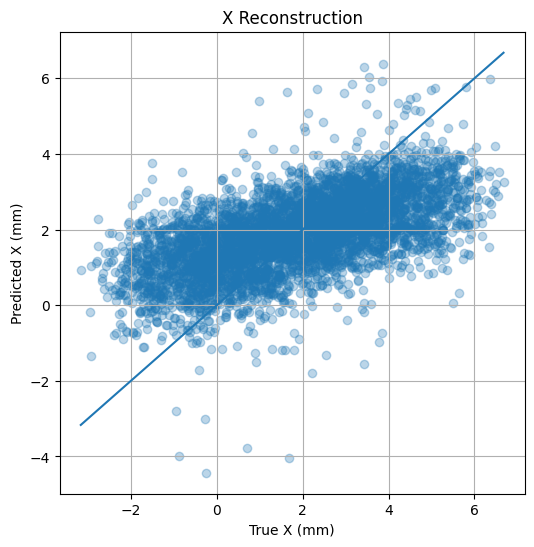

In [56]:
# X
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,0],
    prediction[:,0],
    alpha=0.3
)

plt.xlabel("True X (mm)")
plt.ylabel("Predicted X (mm)")
plt.title("X Reconstruction")

plt.plot(
    [y_test[:,0].min(), y_test[:,0].max()],
    [y_test[:,0].min(), y_test[:,0].max()]
)

plt.grid()
plt.show()

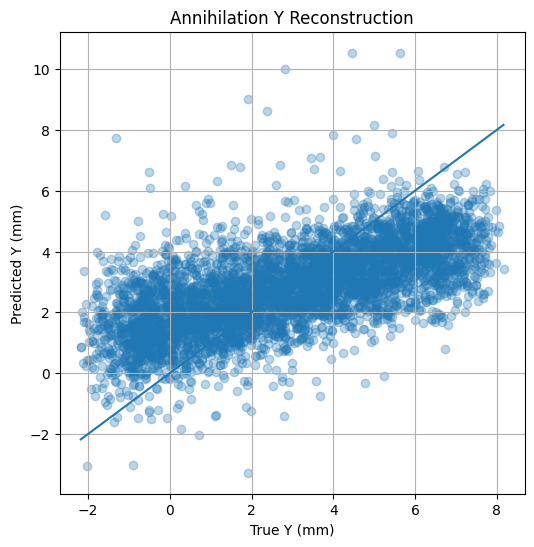

In [57]:
#Y
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,1],          # True Y
    prediction[:,1],      # Predicted Y
    alpha=0.3
)

plt.xlabel("True Y (mm)")
plt.ylabel("Predicted Y (mm)")

plt.title("Annihilation Y Reconstruction")


plt.plot(
    [y_test[:,1].min(), y_test[:,1].max()],
    [y_test[:,1].min(), y_test[:,1].max()]
)

plt.grid()
plt.show()

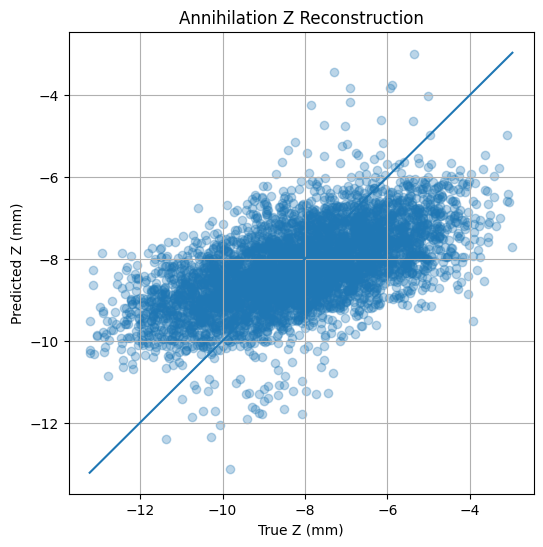

In [58]:
#Z
plt.figure(figsize=(6,6))

plt.scatter(
    y_test[:,2],          # True Z
    prediction[:,2],      # Predicted Z
    alpha=0.3
)

plt.xlabel("True Z (mm)")
plt.ylabel("Predicted Z (mm)")

plt.title("Annihilation Z Reconstruction")


plt.plot(
    [y_test[:,2].min(), y_test[:,2].max()],
    [y_test[:,2].min(), y_test[:,2].max()]
)

plt.grid()
plt.show()

In [31]:
# comparing to baseline
mean_position = np.mean(y_train, axis=0)

print(mean_position)
baseline_prediction = np.tile(
    mean_position,
    (len(y_test),1)
)

from sklearn.metrics import mean_squared_error

baseline_mse = mean_squared_error(
    y_test,
    baseline_prediction
)

cnn_mse = mean_squared_error(
    y_test,
    prediction
)

print("Baseline MSE:", baseline_mse)
print("CNN MSE:", cnn_mse)

[ 1.8453559  2.9287858 -8.15671  ]
Baseline MSE: 4.707585334777832
CNN MSE: 3.4971885681152344


In [32]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

cnn_mae = mean_absolute_error(
    y_test,
    prediction
)

print("Baseline MAE:", baseline_mae)
print("CNN MAE:", cnn_mae)

Baseline MAE: 1.8075875043869019
CNN MAE: 1.5110403299331665


In [33]:
#comparing x,y,z separately
for i, coord in enumerate(["X","Y","Z"]):

    baseline = mean_absolute_error(
        y_test[:,i],
        baseline_prediction[:,i]
    )

    cnn = mean_absolute_error(
        y_test[:,i],
        prediction[:,i]
    )

    print(coord)
    print("Baseline:", baseline)
    print("CNN:", cnn)
    print()

X
Baseline: 1.6673718690872192
CNN: 1.375876545906067

Y
Baseline: 2.207219362258911
CNN: 1.67249596118927

Z
Baseline: 1.5481683015823364
CNN: 1.4847501516342163



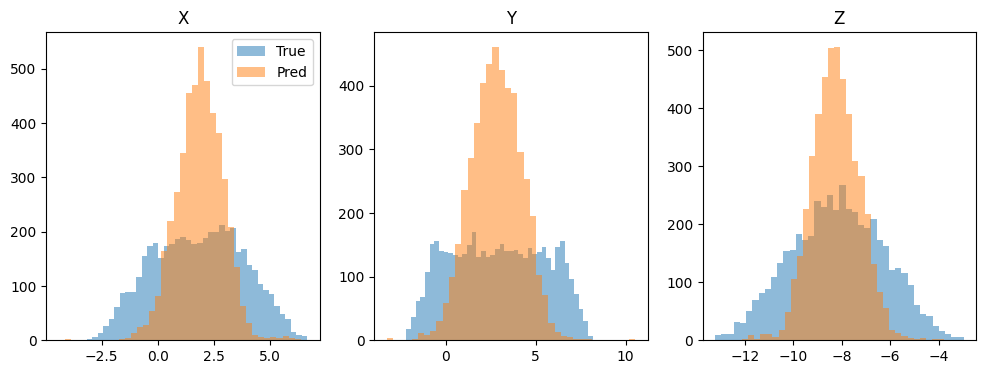

In [59]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(y_test[:,0], bins=40, alpha=0.5, label="True")
plt.hist(prediction[:,0], bins=40, alpha=0.5, label="Pred")
plt.title("X")

plt.legend()

plt.subplot(1,3,2)
plt.hist(y_test[:,1], bins=40, alpha=0.5)
plt.hist(prediction[:,1], bins=40, alpha=0.5)
plt.title("Y")

plt.subplot(1,3,3)
plt.hist(y_test[:,2], bins=40, alpha=0.5)
plt.hist(prediction[:,2], bins=40, alpha=0.5)
plt.title("Z")

plt.show()

In [35]:
print("True Z std:", np.std(y_test[:,2]))
print("Predicted Z std:", np.std(prediction[:,2]))


True Z std: 1.8978516
Predicted Z std: 0.50239307
